In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        os.path.join(dirname, filename)

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

23850
44
8
writer_id
W27    550
W17    550
W01    550
W24    550
W11    550
Name: count, dtype: int64
writer_id
W51    550
W32    550
W25    550
W50    450
W39    300
Name: count, dtype: int64


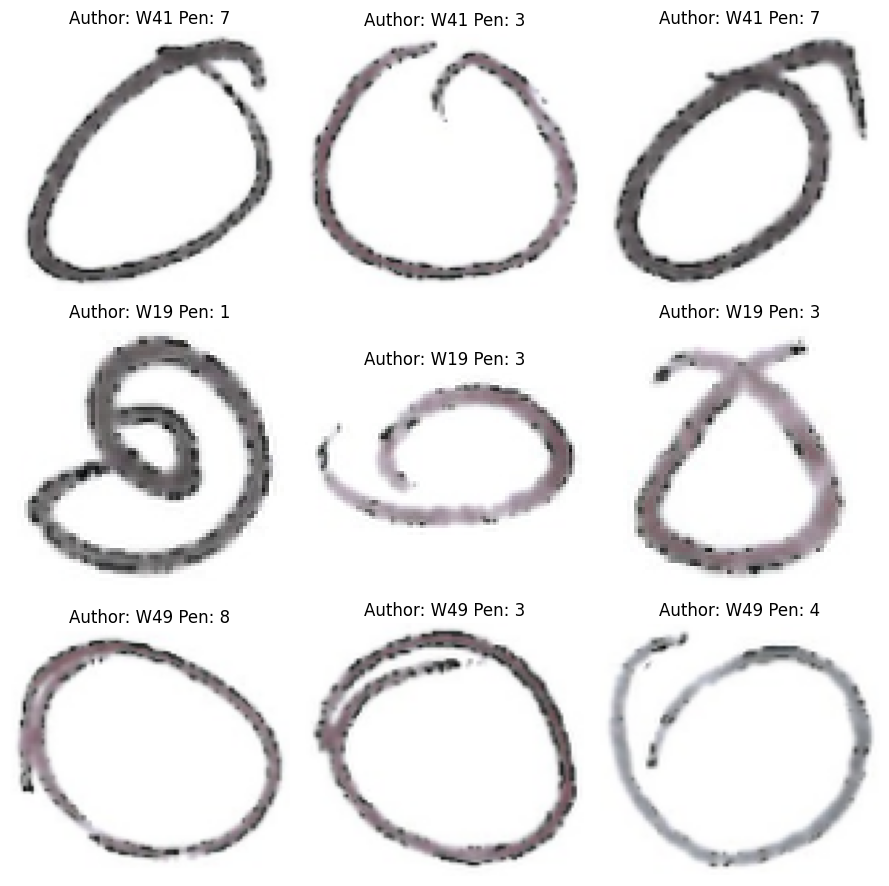

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import random
import os

df = pd.read_csv('/kaggle/input/competitions/icdar-2026-circleid-writer-identification/train.csv')

print(len(df))
print(df['writer_id'].nunique())
print(df['pen_id'].nunique())

writer_counts = df['writer_id'].value_counts()
print(writer_counts.head())
print(writer_counts.tail())

sample_writers = random.sample(list(df['writer_id'].unique()), 3)

DATA_DIR = '/kaggle/input/competitions/icdar-2026-circleid-writer-identification'

plt.figure(figsize=(9, 9))
plot_idx = 1

for writer in sample_writers:
    writer_imgs = df[df['writer_id'] == writer]['image_path'].sample(3).values
    
    for img_path in writer_imgs:
        plt.subplot(3, 3, plot_idx)
        full_path = os.path.join(DATA_DIR, img_path)
        img = mpimg.imread(full_path)
        plt.imshow(img, cmap='gray')
        pen = df[df['image_path'] == img_path]['pen_id'].values[0]
        plt.title(f"Author: {writer} Pen: {pen}")
        plt.axis('off')
        plot_idx += 1

plt.tight_layout()
plt.show()

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import os
import pandas as pd
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['writer_id'])

class CircleDataset(Dataset):
    def __init__(self, dataframe, data_dir, transform=None):
        self.dataframe = dataframe
        self.data_dir = data_dir
        self.transform = transform
        self.label_to_paths = dataframe.groupby('label')['image_path'].apply(list).to_dict()
        self.labels = list(self.label_to_paths.keys())
        
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        anchor_path = self.dataframe.iloc[idx]['image_path']
        anchor_label = self.dataframe.iloc[idx]['label']
        positive_path = random.choice(self.label_to_paths[anchor_label])
        while positive_path == anchor_path:
            positive_path = random.choice(self.label_to_paths[anchor_label])
        
        negative_label = random.choice([l for l in self.labels if l != anchor_label])
        negative_path = random.choice(self.label_to_paths[negative_label])

        def load_image(img_name):
            img_path = os.path.join(self.data_dir, img_name)
            img = Image.open(img_path).convert('RGB')
            if self.transform:
                img = self.transform(img)
            return img

        anchor_img = load_image(anchor_path)
        positive_img = load_image(positive_path)
        negative_img = load_image(negative_path)
        return anchor_img, positive_img, negative_img

base_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = CircleDataset(dataframe=df, data_dir=DATA_DIR, transform=base_transform)

train_loader = DataLoader(train_dataset, 
                    batch_size=32, 
                    shuffle=True,
                    num_workers=4,
                    pin_memory=True
                )

anchors, positives, negatives = next(iter(train_loader))
print(anchors.shape)
print(positives.shape)
print(negatives.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32, 3, 224, 224])
torch.Size([32, 3, 224, 224])


In [4]:
import torch.nn as nn
import torchvision.models as models

class CircleEmbeddingNet(nn.Module):
    def __init__(self, embedding_size=128):
        super().__init__()
        self.backbone = models.resnet18(weights='DEFAULT')
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(num_features, embedding_size)
    def forward(self, x):
        return self.backbone(x)

model = CircleEmbeddingNet(embedding_size=128)
triplet_loss_fn = nn.TripletMarginLoss(margin=1.0, p=2)

emb_a = model(anchors)
emb_p = model(positives)
emb_n = model(negatives)

loss = triplet_loss_fn(emb_a, emb_p, emb_n)

print(emb_a.shape)
print(loss.item())

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 175MB/s]


torch.Size([32, 128])
0.6878148913383484


In [5]:
import torch.optim as optim
from tqdm import tqdm
import copy
from scipy.spatial.distance import cdist

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(device)

cuda


In [6]:
optimizer = optim.Adam(model.parameters(), lr=0.0001)

epochs = 500
best_loss = float('inf')
best_model_weights = None

patience = 15
epochs_not_improve = 0

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    pbar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}', mininterval=60.0)

    for anchors, positives, negatives in pbar:
        anchors = anchors.to(device)
        positives = positives.to(device)
        negatives = negatives.to(device)
        optimizer.zero_grad()
        emb_a = model(anchors)
        emb_p = model(positives)
        emb_n = model(negatives)
        loss = triplet_loss_fn(emb_a, emb_p, emb_n)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item()}'})

    avg_loss = running_loss / len(train_loader)
    print(f'Epoch {epoch+1} done, Avg Loss: {avg_loss}')

    if avg_loss < best_loss:
        best_loss = avg_loss
        best_model_weights = copy.deepcopy(model.state_dict())
        epochs_not_improve = 0
    else:
        epochs_not_improve += 1
        if epochs_not_improve >= patience:
            break

model.load_state_dict(best_model_weights)
model.eval()

Epoch 1/500: 100%|██████████| 746/746 [03:42<00:00,  3.35it/s, loss=0.37102898955345154]


Epoch 1 done, Avg Loss: 0.4218224226209977


Epoch 2/500: 100%|██████████| 746/746 [03:54<00:00,  3.19it/s, loss=0.20344951748847961]


Epoch 2 done, Avg Loss: 0.31762085229797593


Epoch 3/500: 100%|██████████| 746/746 [03:54<00:00,  3.18it/s, loss=0.0668884739279747]


...

Epoch 107/500: 100%|██████████| 746/746 [03:40<00:00,  3.38it/s, loss=0.0]


Epoch 107 done, Avg Loss: 0.01043419076514308


Epoch 108/500: 100%|██████████| 746/746 [03:40<00:00,  3.39it/s, loss=0.04263296350836754]

Epoch 108 done, Avg Loss: 0.00910782963337112


CircleEmbeddingNet(
  (backbone): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=Tru

In [7]:
class SimpleCircleDataset(Dataset):
    def __init__(self, dataframe, data_dir, transform=None, is_test=False):
        self.dataframe = dataframe
        self.data_dir = data_dir
        self.transform = transform
        self.is_test = is_test
    def __len__(self):
        return len(self.dataframe)
    def __getitem__(self, idx):
        img_path_rel = self.dataframe.iloc[idx]['image_path']
        img_path = os.path.join(self.data_dir, img_path_rel)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        if self.is_test:
            image_id = self.dataframe.iloc[idx]['image_id']
            return image, image_id
        else:
            label = self.dataframe.iloc[idx]['label']
            return image, label

In [8]:
def extract_embeddings(loader):
    embs, lbls = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            embs.append(model(images).cpu().numpy())
            if isinstance(labels, torch.Tensor):
                lbls.append(labels.numpy())
            else:
                lbls.extend(labels)
    if isinstance(lbls[0], str):
        lbls = np.array(lbls)
    else:
        lbls = np.concatenate(lbls)
    return np.vstack(embs), lbls

extract_dataset = SimpleCircleDataset(dataframe=df, data_dir=DATA_DIR, transform=base_transform, is_test=False)
extract_loader = torch.utils.data.DataLoader(extract_dataset, batch_size=64, shuffle=False)

test_df = pd.read_csv(os.path.join(DATA_DIR, 'test.csv'))
test_dataset = SimpleCircleDataset(dataframe=test_df, data_dir=DATA_DIR, transform=base_transform, is_test=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

X_train, y_train = extract_embeddings(extract_loader)
X_test, test_ids = extract_embeddings(test_loader)

clusters = {}
for i in range(len(y_train)):
    label = y_train[i]
    if label not in clusters:
        clusters[label] = []
    clusters[label].append(X_train[i])

for label in clusters:
    clusters[label] = np.array(clusters[label])

In [9]:
#tsne = TSNE(n_components=2, random_state=42, perplexity=30)
#embeddings_2d = tsne.fit_transform(all_embeddings)

#plt.figure(figsize=(14, 10))
#scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=all_labels, cmap='tab20', alpha=0.7, s=20)
#plt.colorbar(scatter, label='Author ID')
#plt.xlabel('Dim 1')
#plt.ylabel('Dim 2')
#plt.show()

In [10]:
cluster_thresholds = {}
k_neighbors = 3

for label, cluster_points in clusters.items():
    intra_dists = cdist(cluster_points, cluster_points, metric='euclidean')
    avg_intra_dists = np.sort(intra_dists, axis=1)[:, 1:k_neighbors+1].mean(axis=1)
    cluster_thresholds[label] = np.percentile(avg_intra_dists, 95)

def predict_test_point(query_emb, multiplier=1.5):
    best_label = -1
    min_score = float('inf')
    
    for label, points in clusters.items():
        dists = np.linalg.norm(points - query_emb, axis=1)
        k_nearest = np.partition(dists, min(k_neighbors, len(dists))-1)[:k_neighbors]
        score = np.mean(k_nearest)
        if score < min_score:
            min_score = score
            best_label = label
            
    if best_label != -1:
        dynamic_limit = cluster_thresholds[best_label] * multiplier
        if min_score > dynamic_limit:
            return -1

    return best_label

final_predictions = [predict_test_point(emb) for emb in X_test]

final_labels = []

for pred in final_predictions:
    if pred == -1:
        final_labels.append('-1')
    else:
        orig_id = le.inverse_transform([pred])[0]
        final_labels.append(orig_id)

submission_df = pd.DataFrame({
    'image_id': test_ids,
    'writer_id': final_labels
})

submission_df.to_csv('submission.csv', index=False)

In [11]:
print(submission_df.shape)

(5905, 2)
